In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

In [2]:
# Load Iris dataset
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

print("Dataset Shape:", X.shape)
print("\nFeatures:")
print(X.head())

print("\nTarget Classes:")
print(iris.target_names)

Dataset Shape: (150, 4)

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target Classes:
['setosa' 'versicolor' 'virginica']


In [3]:
print("Dataset Information:")
print(X.info())

print("\nClass Distribution:")
print(y.value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [5]:
# Create Gaussian Naive Bayes model
model_all = GaussianNB()

# Train model
model_all.fit(X_train, y_train)

# Prediction
y_pred_all = model_all.predict(X_test)

# Evaluation
accuracy_all = accuracy_score(y_test, y_pred_all)
precision_all = precision_score(y_test, y_pred_all, average='weighted')
recall_all = recall_score(y_test, y_pred_all, average='weighted')

print("Naïve Bayes - All Features")
print("--------------------------------")
print("Accuracy :", accuracy_all)
print("Precision:", precision_all)
print("Recall   :", recall_all)

Naïve Bayes - All Features
--------------------------------
Accuracy : 0.9666666666666667
Precision: 0.9696969696969696
Recall   : 0.9666666666666667


In [6]:
feature_sets = {
    "Sepal Features": [0, 1],
    "Petal Features": [2, 3],
    "All Features": [0, 1, 2, 3]
}

results = []

for name, features in feature_sets.items():

    X_subset = X.iloc[:, features]

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_subset, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = GaussianNB()
    model.fit(X_train_s, y_train_s)

    y_pred = model.predict(X_test_s)

    accuracy = accuracy_score(y_test_s, y_pred)
    precision = precision_score(
        y_test_s, y_pred, average='weighted'
    )
    recall = recall_score(
        y_test_s, y_pred, average='weighted'
    )

    results.append([
        name,
        accuracy,
        precision,
        recall
    ])

results_df = pd.DataFrame(
    results,
    columns=["Feature Set", "Accuracy", "Precision", "Recall"]
)

results_df

,Feature Set,Accuracy,Precision,Recall
0,Sepal Features,0.700000,0.700337,0.700000
1,Petal Features,0.966667,0.969697,0.966667
2,All Features,0.966667,0.969697,0.966667


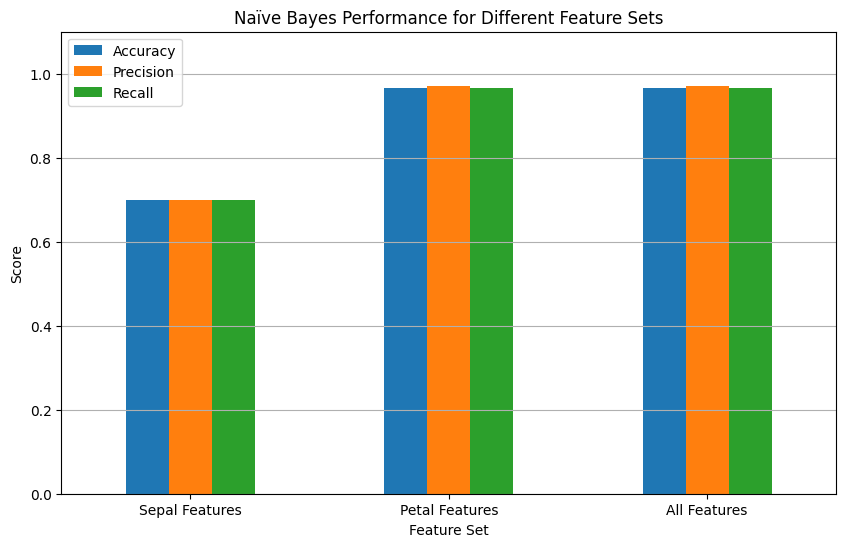

In [7]:
results_df.set_index("Feature Set").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Naïve Bayes Performance for Different Feature Sets")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [8]:
from sklearn.naive_bayes import CategoricalNB

# Convert continuous values into 3 categories
X_cat = X.copy()

for column in X_cat.columns:
    X_cat[column] = pd.qcut(
        X_cat[column],
        q=3,
        labels=False,
        duplicates='drop'
    )

print(X_cat.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  0                 2                  0                 0
1                  0                 1                  0                 0
2                  0                 1                  0                 0
3                  0                 1                  0                 0
4                  0                 2                  0                 0


In [9]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
# alpha = 0 means no Laplace smoothing
model_no_smoothing = CategoricalNB(alpha=0)

model_no_smoothing.fit(X_train_cat, y_train_cat)

y_pred_no = model_no_smoothing.predict(X_test_cat)

accuracy_no = accuracy_score(y_test_cat, y_pred_no)
precision_no = precision_score(
    y_test_cat, y_pred_no, average='weighted'
)
recall_no = recall_score(
    y_test_cat, y_pred_no, average='weighted'
)

print("Without Laplace Smoothing")
print("--------------------------")
print("Accuracy :", accuracy_no)
print("Precision:", precision_no)
print("Recall   :", recall_no)

Without Laplace Smoothing
--------------------------
Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:1528: RuntimeWarning: divide by zero encountered in log
  np.log(smoothed_cat_count) - np.log(smoothed_class_count.reshape(-1, 1))


In [11]:
# alpha = 1 applies Laplace smoothing
model_smoothing = CategoricalNB(alpha=1)

model_smoothing.fit(X_train_cat, y_train_cat)

y_pred_smooth = model_smoothing.predict(X_test_cat)

accuracy_smooth = accuracy_score(y_test_cat, y_pred_smooth)
precision_smooth = precision_score(
    y_test_cat, y_pred_smooth, average='weighted'
)
recall_smooth = recall_score(
    y_test_cat, y_pred_smooth, average='weighted'
)

print("With Laplace Smoothing")
print("----------------------")
print("Accuracy :", accuracy_smooth)
print("Precision:", precision_smooth)
print("Recall   :", recall_smooth)

With Laplace Smoothing
----------------------
Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333


In [12]:
smoothing_results = pd.DataFrame({
    "Method": [
        "Without Laplace Smoothing",
        "With Laplace Smoothing"
    ],
    "Accuracy": [
        accuracy_no,
        accuracy_smooth
    ],
    "Precision": [
        precision_no,
        precision_smooth
    ],
    "Recall": [
        recall_no,
        recall_smooth
    ]
})

print(smoothing_results)

                      Method  Accuracy  Precision    Recall
0  Without Laplace Smoothing  0.933333   0.933333  0.933333
1     With Laplace Smoothing  0.933333   0.933333  0.933333


In [13]:
# Get probability estimates
probabilities = model_smoothing.predict_proba(X_test_cat)

probability_df = pd.DataFrame(
    probabilities,
    columns=iris.target_names
)

print("Class Probability Estimates:")
print(probability_df.head(10))

Class Probability Estimates:
     setosa  versicolor  virginica
0  0.999917    0.000049   0.000034
1  0.000768    0.374027   0.625206
2  0.000591    0.995469   0.003940
3  0.000591    0.995469   0.003940
4  0.999917    0.000049   0.000034
5  0.001018    0.970798   0.028184
6  0.999984    0.000005   0.000011
7  0.999984    0.000005   0.000011
8  0.000027    0.000667   0.999306
9  0.007437    0.984175   0.008388


In [14]:
prediction_df = pd.DataFrame({
    "Actual": y_test_cat.values,
    "Predicted": y_pred_smooth,
    "Setosa Probability": probabilities[:, 0],
    "Versicolor Probability": probabilities[:, 1],
    "Virginica Probability": probabilities[:, 2]
})

print(prediction_df.head(10))

   Actual  Predicted  Setosa Probability  Versicolor Probability  \
0       0          0            0.999917                0.000049   
1       2          2            0.000768                0.374027   
2       1          1            0.000591                0.995469   
3       1          1            0.000591                0.995469   
4       0          0            0.999917                0.000049   
5       1          1            0.001018                0.970798   
6       0          0            0.999984                0.000005   
7       0          0            0.999984                0.000005   
8       2          2            0.000027                0.000667   
9       1          1            0.007437                0.984175   

   Virginica Probability  
0               0.000034  
1               0.625206  
2               0.003940  
3               0.003940  
4               0.000034  
5               0.028184  
6               0.000011  
7               0.000011  
8       

In [15]:
alpha_values = [0, 0.01, 0.1, 0.5, 1, 2, 5]

alpha_results = []

for alpha in alpha_values:

    model = CategoricalNB(alpha=alpha)
    model.fit(X_train_cat, y_train_cat)

    y_pred = model.predict(X_test_cat)

    acc = accuracy_score(y_test_cat, y_pred)
    prec = precision_score(
        y_test_cat, y_pred, average='weighted'
    )
    rec = recall_score(
        y_test_cat, y_pred, average='weighted'
    )

    alpha_results.append([
        alpha, acc, prec, rec
    ])

alpha_df = pd.DataFrame(
    alpha_results,
    columns=["Alpha", "Accuracy", "Precision", "Recall"]
)

alpha_df

/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:1528: RuntimeWarning: divide by zero encountered in log
  np.log(smoothed_cat_count) - np.log(smoothed_class_count.reshape(-1, 1))


,Alpha,Accuracy,Precision,Recall
0,0.00,0.933333,0.933333,0.933333
1,0.01,0.933333,0.933333,0.933333
2,0.10,0.933333,0.933333,0.933333
3,0.50,0.933333,0.933333,0.933333
4,1.00,0.933333,0.933333,0.933333
5,2.00,0.933333,0.933333,0.933333
6,5.00,0.933333,0.933333,0.933333


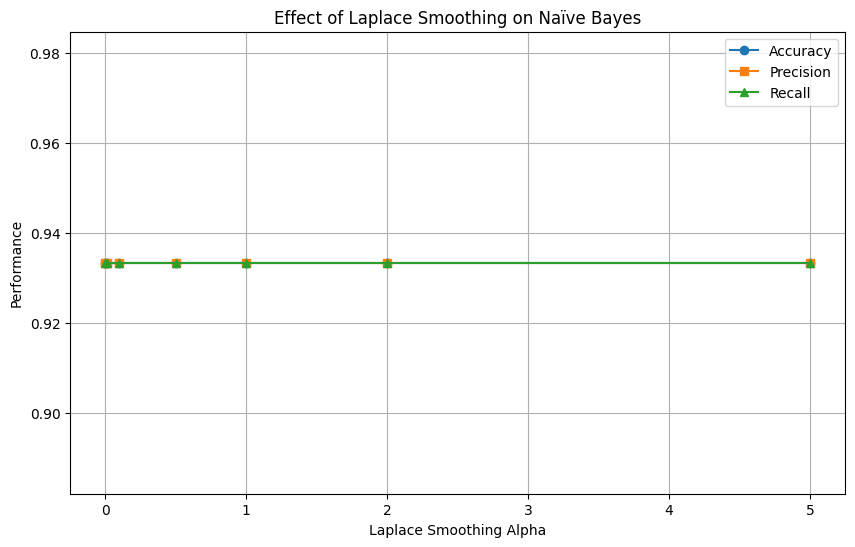

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    alpha_df["Alpha"],
    alpha_df["Accuracy"],
    marker='o',
    label="Accuracy"
)

plt.plot(
    alpha_df["Alpha"],
    alpha_df["Precision"],
    marker='s',
    label="Precision"
)

plt.plot(
    alpha_df["Alpha"],
    alpha_df["Recall"],
    marker='^',
    label="Recall"
)

plt.xlabel("Laplace Smoothing Alpha")
plt.ylabel("Performance")
plt.title("Effect of Laplace Smoothing on Naïve Bayes")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
final_results = pd.DataFrame({
    "Experiment": [
        "All Features - GaussianNB",
        "Sepal Features",
        "Petal Features",
        "CategoricalNB - No Smoothing",
        "CategoricalNB - Laplace Smoothing"
    ],
    "Accuracy": [
        accuracy_all,
        results_df.loc[results_df["Feature Set"] == "Sepal Features", "Accuracy"].values[0],
        results_df.loc[results_df["Feature Set"] == "Petal Features", "Accuracy"].values[0],
        accuracy_no,
        accuracy_smooth
    ],
    "Precision": [
        precision_all,
        results_df.loc[results_df["Feature Set"] == "Sepal Features", "Precision"].values[0],
        results_df.loc[results_df["Feature Set"] == "Petal Features", "Precision"].values[0],
        precision_no,
        precision_smooth
    ],
    "Recall": [
        recall_all,
        results_df.loc[results_df["Feature Set"] == "Sepal Features", "Recall"].values[0],
        results_df.loc[results_df["Feature Set"] == "Petal Features", "Recall"].values[0],
        recall_no,
        recall_smooth
    ]
})

final_results

,Experiment,Accuracy,Precision,Recall
0,All Features - GaussianNB,0.966667,0.969697,0.966667
1,Sepal Features,0.700000,0.700337,0.700000
2,Petal Features,0.966667,0.969697,0.966667
3,CategoricalNB - No Smoothing,0.933333,0.933333,0.933333
4,CategoricalNB - Laplace Smoothing,0.933333,0.933333,0.933333
